# Beyond GM: Properties, Condition Types, and Workspace

The accelerated backends generate kernels from the symbolic `Model`, so they
are not limited to Gibbs energies: any property the model can express
symbolically — enthalpy, entropy, heat capacity, mixing quantities, degree of
ordering — compiles the same way. This notebook covers:

1. equilibrium output properties (`output='HM'`, ...),
2. `calculate()` property evaluation,
3. the supported condition types (mass fractions, chemical potentials, dilute),
4. `Workspace`.

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pycalphad
from pycalphad import Database, Workspace, calculate, equilibrium, variables as v

# The backend to demonstrate: 'c++' runs generated kernels on the CPU,
# 'gpu' runs the same kernels through CuPy on an NVIDIA or AMD GPU.
BACKEND = 'c++'

def timed(label, fn):
    """Run fn(), print and return (result, elapsed seconds)."""
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f'{label}: {elapsed:.1f} s')
    return result, elapsed


In [2]:
from importlib.resources import files
TESTDB = files('pycalphad.tests.databases')
alni = Database(str(TESTDB / 'alni_dupin_2001.tdb'))
comps = ['AL', 'NI', 'VA']
phases = sorted(alni.phases.keys())

# Warm the kernel cache.
with pycalphad.backend(BACKEND):
    equilibrium(alni, comps, phases, {v.N: 1, v.P: 101325, v.T: 800, v.X('AL'): 0.3});

## 1. Equilibrium output properties

Equilibrium enthalpy, entropy and heat capacity over a temperature-composition
grid. The properties are evaluated at the converged equilibrium states
(phase-amount weighted), exactly as the reference does.

In [3]:
conditions = {v.N: 1, v.P: 101325, v.T: (400, 1800, 25), v.X('AL'): (0.05, 0.95, 0.02)}

ref, t_ref = timed('reference solver   ',
                   lambda: equilibrium(alni, comps, phases, conditions, output=['HM', 'SM']))
with pycalphad.backend(BACKEND):
    acc, t_acc = timed('accelerated backend',
                       lambda: equilibrium(alni, comps, phases, conditions, output=['HM', 'SM']))
print(f'speedup: {t_ref / t_acc:.1f}x')

for prop in ('HM', 'SM'):
    a = np.asarray(acc[prop].values, dtype=float).reshape(-1)
    b = np.asarray(ref[prop].values, dtype=float).reshape(-1)
    both = ~np.isnan(a) & ~np.isnan(b)
    print(f'max |d{prop}|: {np.abs(a[both] - b[both]).max():.3e}')

reference solver   : 4.1 s


accelerated backend: 1.6 s
speedup: 2.6x
max |dHM|: 6.422e-02
max |dSM|: 1.441e-04


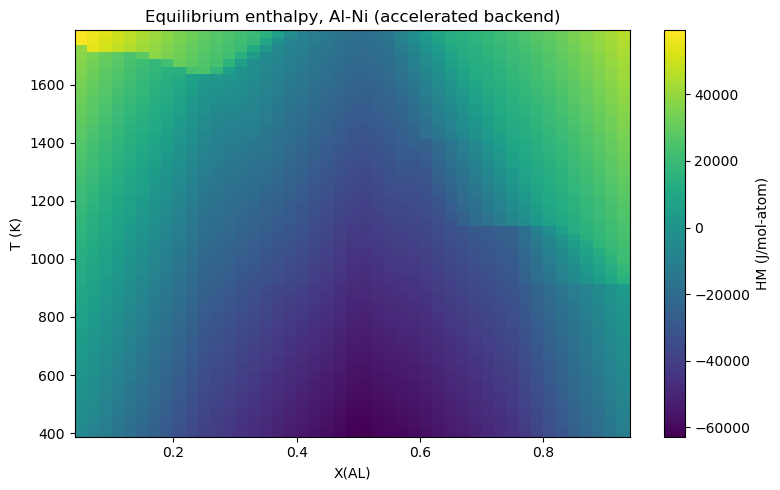

In [4]:
hm = acc.HM.values.squeeze()
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(acc.coords['X_AL'].values, acc.coords['T'].values, hm, shading='nearest')
fig.colorbar(im, label='HM (J/mol-atom)')
ax.set_xlabel('X(AL)'); ax.set_ylabel('T (K)')
ax.set_title('Equilibrium enthalpy, Al-Ni (accelerated backend)')
plt.tight_layout()

## 2. `calculate()` — property evaluation without equilibrium

`calculate()` samples phase internal degrees of freedom directly. Under a
backend, the property kernels replace the reference's compiled-symbol path;
results agree to numerical precision.

In [5]:
ref_c = calculate(alni, comps, phases, output='CPM', T=(300, 2000, 10), P=101325, N=1)
with pycalphad.backend(BACKEND):
    acc_c = calculate(alni, comps, phases, output='CPM', T=(300, 2000, 10), P=101325, N=1)
a, b = np.asarray(acc_c.CPM.values).reshape(-1), np.asarray(ref_c.CPM.values).reshape(-1)
both = ~np.isnan(a) & ~np.isnan(b)
print(f'{int(both.sum())} sampled points, max |dCPM|: {np.abs(a[both] - b[both]).max():.3e} J/mol/K')

17003400 sampled points, max |dCPM|: 4.263e-14 J/mol/K


## 3. Condition types

Mass fractions (`v.W`), chemical-potential conditions (`v.MU`), and dilute or
exactly-zero compositions all dispatch to the backend.

In [6]:
cases = {
    'mass fraction W(AL)=0.05':  {v.N: 1, v.P: 101325, v.T: 1000, v.W('AL'): 0.05},
    'chemical potential MU(AL)': {v.N: 1, v.P: 101325, v.T: 1000, v.MU('AL'): -150000},
    'dilute X(AL)=1e-9':         {v.N: 1, v.P: 101325, v.T: 1000, v.X('AL'): 1e-9},
}
for name, conds in cases.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ref_e = equilibrium(alni, comps, phases, conds)
        with pycalphad.backend(BACKEND):
            acc_e = equilibrium(alni, comps, phases, conds)
    gr = float(np.asarray(ref_e.GM.values).reshape(-1)[0])
    ga = float(np.asarray(acc_e.GM.values).reshape(-1)[0])
    print(f'{name:28s} reference {gr:14.3f}   accelerated {ga:14.3f}   |dGM| {abs(ga - gr):.2e}')

mass fraction W(AL)=0.05     reference     -61227.546   accelerated     -61227.546   |dGM| 5.09e-11


chemical potential MU(AL)    reference     -82874.737   accelerated     -82874.737   |dGM| 1.46e-11


dilute X(AL)=1e-9            reference     -44814.729   accelerated     -44814.729   |dGM| 4.95e-10


## 4. Workspace

`Workspace.recompute` is a dispatch point too: select a backend globally and
`wks.eq`, `wks.get(...)`, and the plotting helpers built on Workspace all use
it — no other code changes.

In [7]:
conditions = {v.N: 1, v.P: 101325, v.T: (400, 1800, 25), v.X('AL'): (0.05, 0.95, 0.02)}

wks = Workspace(alni, comps, phases, conditions)
_, t_ref = timed('Workspace, reference   ', lambda: wks.eq)

pycalphad.set_backend(BACKEND)
wks_acc = Workspace(alni, comps, phases, conditions)
_, t_acc = timed('Workspace, accelerated ', lambda: wks_acc.eq)
pycalphad.set_backend('default')
print(f'speedup: {t_ref / t_acc:.1f}x')

Workspace, reference   : 3.5 s


Workspace, accelerated : 0.8 s
speedup: 4.2x
